<a href="https://colab.research.google.com/github/Fachreza28/pba-task-1a-individual/blob/main/Week2_Scrapping_Apps_Review_MobileJKN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Scrapping Google Apps Review - eg Mobile JKN
Week 2 NLP Pipeline PBA/ Genap 2026/ Irmasari Hafidz irma@its.ac.id

Homework: WEEK 3/ 11 maret 2026 (TUGAS 1)

Re-run google colab ini, dengan dataset apps review masing2.
Berikan analisa sederhana, dan upload di github.


In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00


In [ ]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
#Android App Mobile JKN  from Google Play at
#https://play.google.com/store/apps/details?id=app.bpjs.mobile&hl=id
#ID Apps:
#The apps ID found in the link after id=app.bpjs.mobile&hl=id
#The apps name on Google Play titled: MobileJKN dari Pemerintah Indonesia (Kemenkes)
#Dated 3 March 2025 and N of reviews 787K

from google_play_scraper import app, Sort, reviews_all

jkn_reviews = reviews_all(
    'app.bpjs.mobile',
    sleep_milliseconds=0, # defaults to 0
    lang='en', # defaults to 'en'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [ ]:
#Save Mobile JKN reviews into dataframe
df_jknrev = pd.DataFrame(np.array(jkn_reviews),columns=['content'])
df_jknrev = df_jknrev.join(pd.DataFrame(df_jknrev.pop('content').tolist()))
df_jknrev.to_csv(r'df_jknrev', index=False)

## Homework TUGAS 1A

NLP Pipeline:
RAW data (save to csv) lakukan:

* Tokenization
* Lowering
* Stopword Removal
* Lemmatization
* Stemming
* Punctuations Removal
* Expand Contractions
* Spelling Correction
* Rare Words Removal
* Common Words Removal

(save as cleandata.csv)
* Frequent words (n=50,100,1000)
* Frequent Words found (new), contoh: yg, bs, tyt
* ditambahkan di stopwords removal
* Stopwords removal (NLTK, misal case study review hanya dalam Indonesia n=758)


In [ ]:
df_jknrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,e0834a0c-2c1b-4372-891e-e30d43da2056,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Mohon menu ""Info riwayat pelayanan"" juga di se...",3,0,4.15.0,2026-03-10 02:10:28,None,NaT,4.15.0
1,305e82f2-a78f-47c7-abe3-f443f461bba1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Aplikasi diprotect tidak bisa discreen shot. G...,3,0,4.0.1,2026-03-10 01:59:43,None,NaT,4.0.1
2,ffff770d-de8a-4699-926e-a2129bf076d7,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,ilove this veru useful,5,0,4.15.0,2026-03-09 14:50:56,None,NaT,4.15.0
3,05d25dcb-74e7-480a-b80c-d36ea02012af,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,keren,5,0,4.15.0,2026-03-09 14:08:27,None,NaT,4.15.0
4,2d03dc9d-3201-4f5e-a25e-2df686324007,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Helpfull nice experiance apps,5,0,4.15.0,2026-03-09 09:54:45,None,NaT,4.15.0
...,...,...,...,...,...,...,...,...,...,...,...
29885,04f946aa-28f2-4f1d-88e5-439606a7372e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Semoga di bulan yang penuh rahmah ini amal iba...,5,3,1.1,2016-06-07 08:01:44,Amiin pak Andi :D,2016-06-07 17:54:48,1.1
29886,d9ab15a4-3f3c-4555-9aad-5deeaeec8ced,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Nice,5,0,1.1,2016-06-07 07:46:16,None,NaT,1.1
29887,38e3c54a-155c-4fa7-9012-b301ae02acce,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Sip mantapsssss....,5,1,None,2016-04-18 02:07:53,None,NaT,None
29888,f0118887-f8de-4bc5-8764-cd1e994e2868,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat informatif dan dapat membantu masyarakat.,5,0,1.0,2016-04-18 01:51:54,None,NaT,1.0


In [ ]:
df_jknrev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29890 entries, 0 to 29889
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              29890 non-null  object        
 1   userName              29890 non-null  object        
 2   userImage             29890 non-null  object        
 3   content               29889 non-null  object        
 4   score                 29890 non-null  int64         
 5   thumbsUpCount         29890 non-null  int64         
 6   reviewCreatedVersion  25493 non-null  object        
 7   at                    29890 non-null  datetime64[ns]
 8   replyContent          18889 non-null  object        
 9   repliedAt             18889 non-null  datetime64[ns]
 10  appVersion            25493 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 2.5+ MB


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_analysis = df_jknrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

In [ ]:
#Check number of reviews scores
df_jknrev['score'].value_counts()

,count
score,
1,13180
5,11496
2,1964
4,1690
3,1560


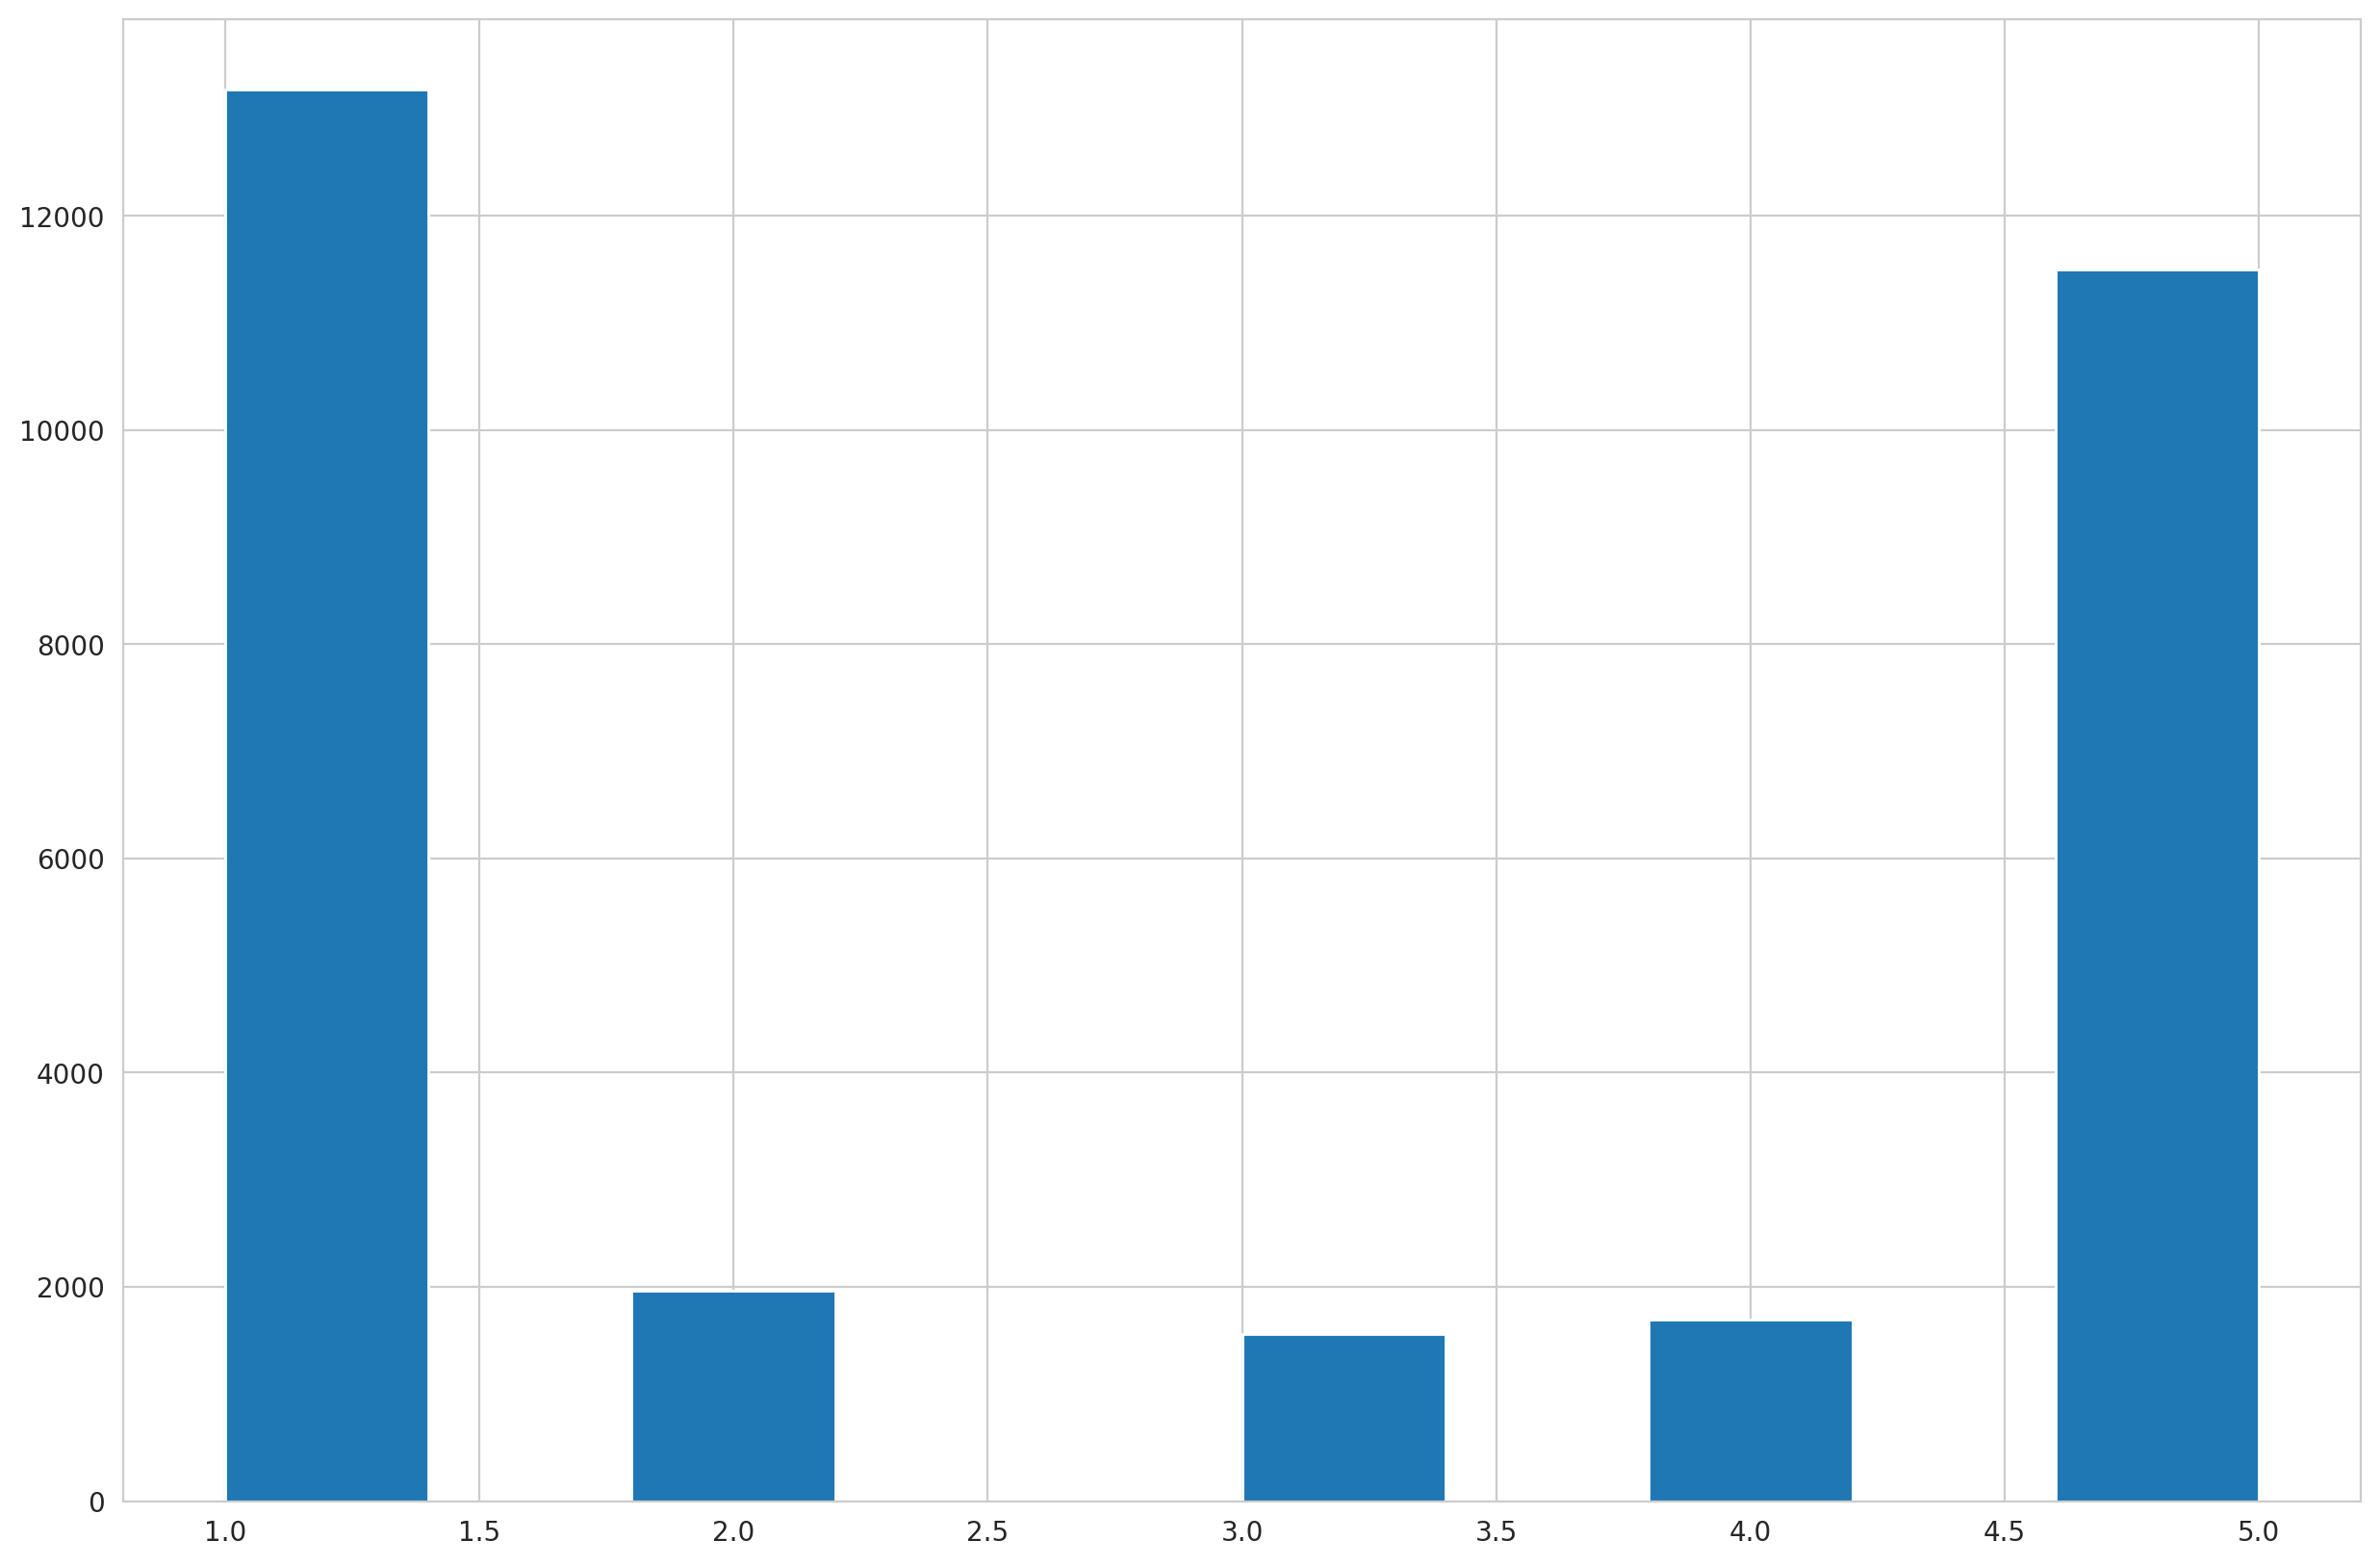

In [ ]:
plt.hist(df_jknrev['score'])
plt.show()

In [ ]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.3 MB/s eta 0:00:00


In [ ]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_jknrev['sentiment_polarity'] = df_jknrev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_jknrev['sentiment_subjective'] = df_jknrev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [ ]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"Mohon menu ""Info riwayat pelayanan"" juga di sediakan selector anggota keluarga",3,0.0,0.0
1,"Aplikasi diprotect tidak bisa discreen shot. Gunanya apaan ya? untuk ngurus2 admin sulit yang terkadang perlu screenshot, justru dimatikan. Lalu yang paling menyebalkan tiap berapa detik langsung ...",3,0.0,0.0
2,ilove this veru useful,5,0.3,0.0
3,keren,5,0.0,0.0
4,Helpfull nice experiance apps,5,0.6,1.0
...,...,...,...,...
29885,Semoga di bulan yang penuh rahmah ini amal ibadah kita diterima Allah SWT. Dan bagi para developer serta pihak2 yg membantu proses pengembangan aplikasi ini mendapatkan pahala. Amiiin,5,0.0,0.0
29886,Nice,5,0.6,1.0
29887,Sip mantapsssss....,5,0.0,0.0
29888,Sangat informatif dan dapat membantu masyarakat.,5,0.0,0.0


## Lowercasing

In [ ]:
#DATA PREPROCESSING
# Lower casing
# Change the reviews type to string
df_jknrev['content'] = df_jknrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_jknrev['content'][188])
print(df_jknrev['content'][1])
print(df_jknrev['content'][20100])

Gini amat yak hasil duit pajak, verif wajah gapernah bisa, otp gapernah kekirim
kenapa susah sekali utk login. saya udah bayar lebih dr 2 th rp. 150.000 perbulan???
Gak bisa digunakan


In [ ]:
#Lowercase all reviews to see the difference
df_jknrev['content']= df_jknrev['content'].apply(lambda x: x.lower())
print(df_jknrev['content'][188])
print(df_jknrev['content'][1])
print(df_jknrev['content'][20100])

gini amat yak hasil duit pajak, verif wajah gapernah bisa, otp gapernah kekirim
kenapa susah sekali utk login. saya udah bayar lebih dr 2 th rp. 150.000 perbulan???
gak bisa digunakan


##Stopwords Removal
Indonesian Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords[:20])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


In [ ]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_jknrev['wordCount'] = [len(review.split()) for review in df_jknrev['content']]
df_jknrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_jknrev['content']]
df_jknrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_jknrev['content']]

In [ ]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

NameError: name 'df_jknrev' is not defined

In [ ]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_jknrev['sentiment_rating'] = df_jknrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [ ]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"ketika daftar pakai otp, tapi otp nya udh dicoba pulahan kali di beberapa nomer gak masuk",1,0.0,0.0,Negative
1,"bagua aplikasinya, semoga ditingkatkan pelayanannya, rumah sakit atau puskesmas atau faskes lain mudah mendapatkan dana dari bpjs untuk melayani masyarakat",5,0.0,0.0,Positive
2,"waktu estimasi menunggu bodoh banget ampe 3 jam, baru 30 menit nomor antrian gw ke skip, gak didahuluin. harus nunggu dari awal lagi",1,0.0,0.0,Negative
3,"setipa verifikasi otp gagal terus, alasannya koneksi offline, padahal internet kenceng. tolong di perbaiki, saya mau pindah faskes jadi ga bisa. makasih",1,0.0,0.0,Negative
4,"mau bikin akun susah bangett, kode otp nomer handphone ngga dapet mulu😤",2,0.0,0.0,Negative
...,...,...,...,...,...
26683,semoga di bulan yang penuh rahmah ini amal ibadah kita diterima allah swt. dan bagi para developer serta pihak2 yg membantu proses pengembangan aplikasi ini mendapatkan pahala. amiiin,5,0.0,0.0,Positive
26684,nice,5,0.6,1.0,Positive
26685,sip mantapsssss....,5,0.0,0.0,Positive
26686,sangat informatif dan dapat membantu masyarakat.,5,0.0,0.0,Positive


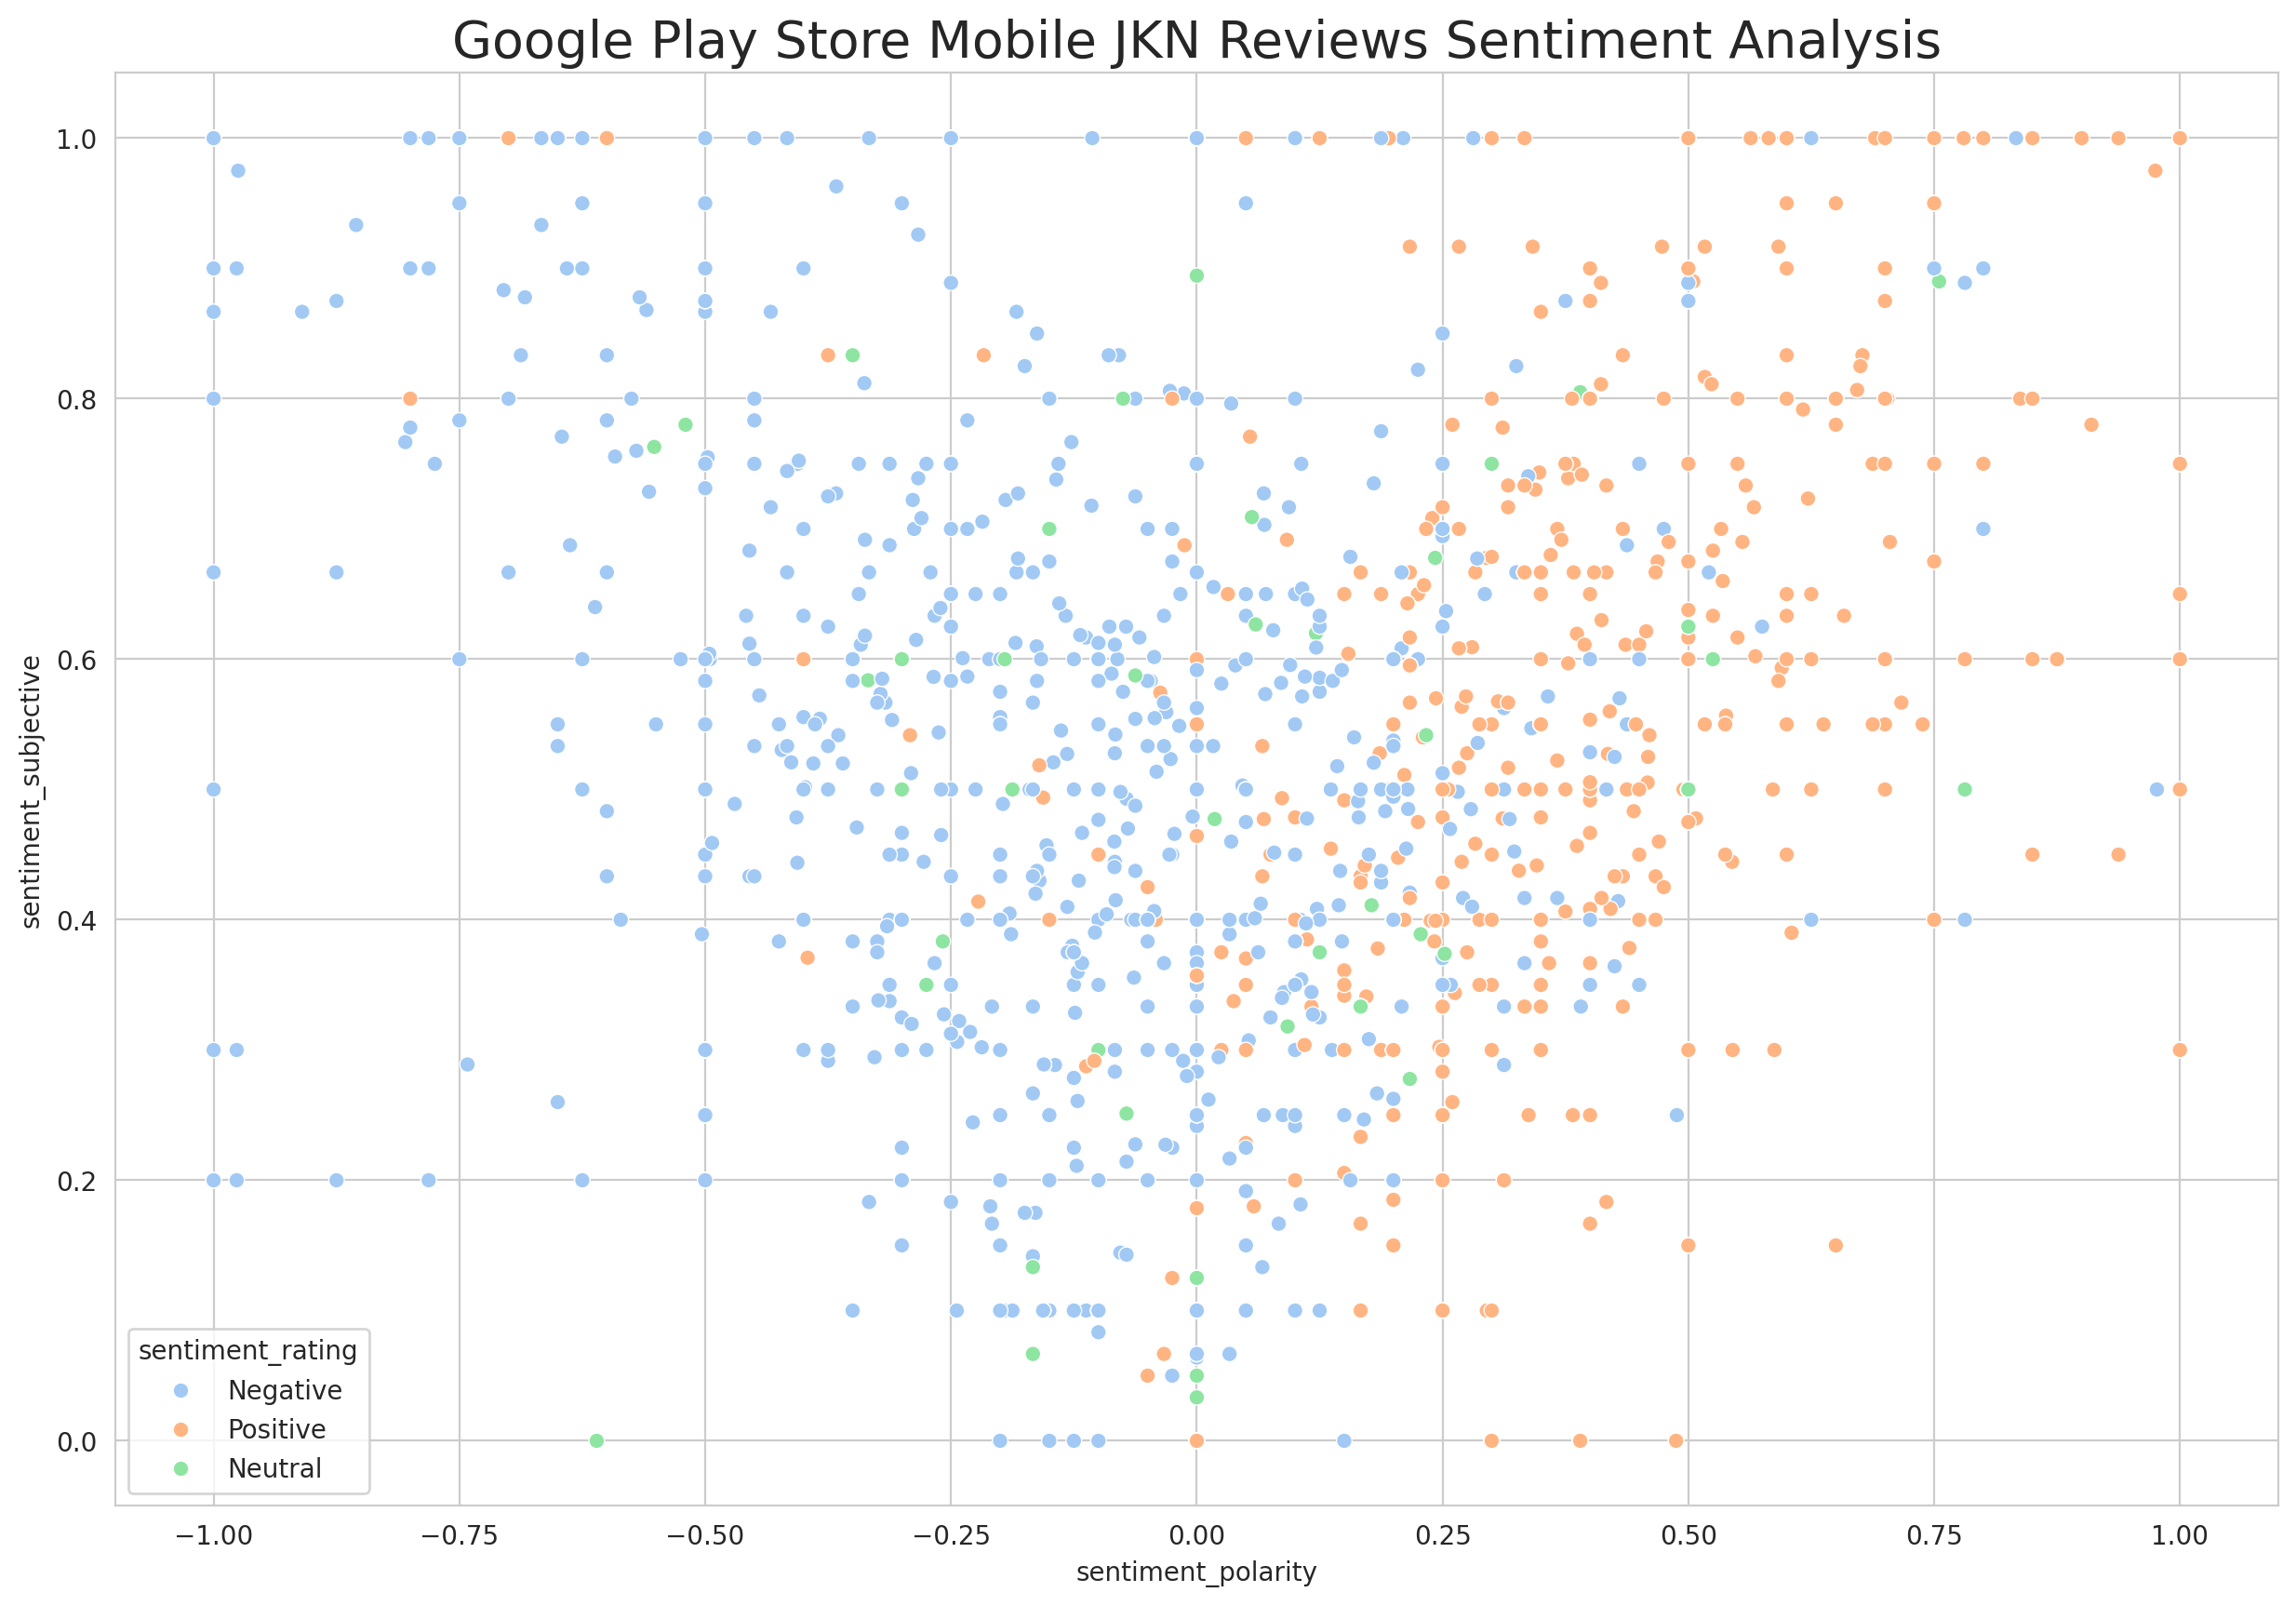

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_jknrev['sentiment_polarity'], y=df_jknrev['sentiment_subjective'],
                hue=df_jknrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Mobile JKN Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

<ipython-input-56-4d03cb5e9bb2>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


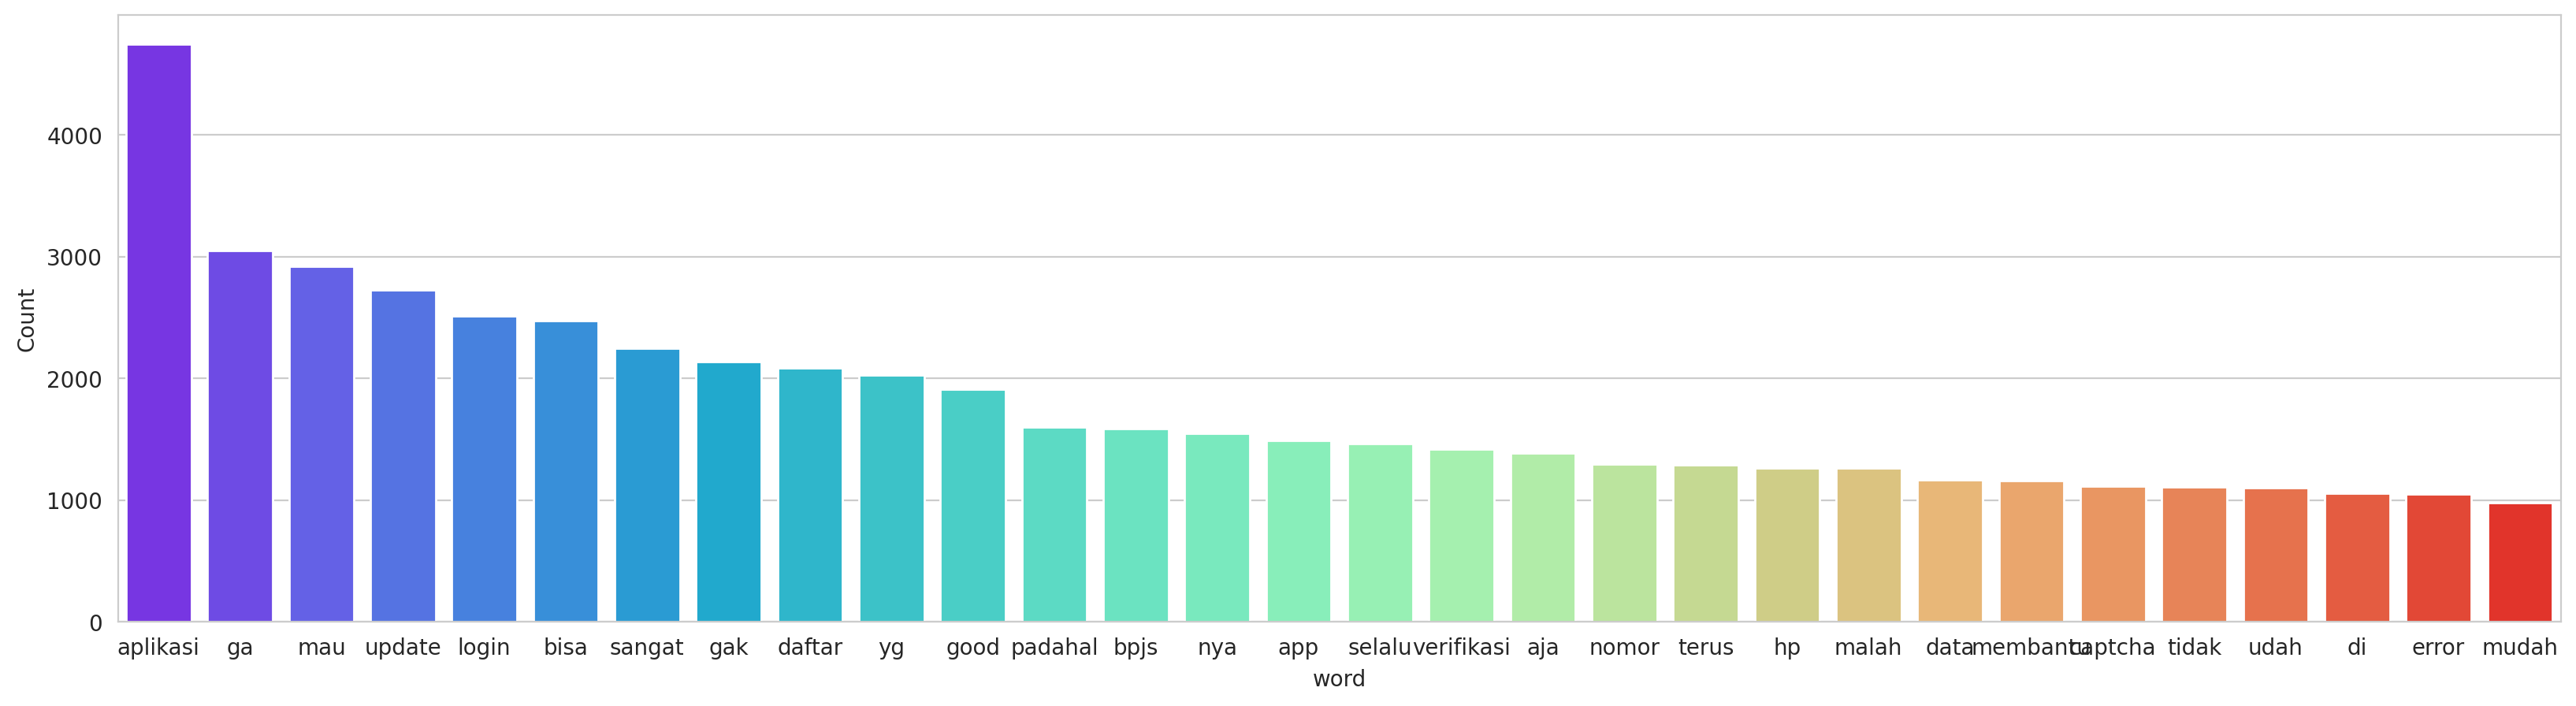

In [ ]:
freq_words(df_jknrev['content'])

In [ ]:
# prompt: the [content] column hasnt been applied Indonesian stopwords removal using Sastrawi

!pip install Sastrawi

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Create stopword remover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Apply stopword removal to the 'content' column
df_jknrev['content'] = df_jknrev['content'].apply(lambda x: stopword_remover.remove(x))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.5 MB/s eta 0:00:00


In [ ]:
# prompt: can you also apply English stopwords as well to the [content] column

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get English stopwords
english_stopwords = stopwords.words('english')

# Assuming df_jknrev is your DataFrame and 'content' is the column
df_jknrev['content'] = df_jknrev['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in english_stopwords]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
english_stopwords(len)

NameError: name 'english_stopwords' is not defined

In [ ]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"daftar pakai otp, otp nya udh dicoba pulahan kali beberapa nomer gak masuk",1,0.0,0.0,Negative
1,"bagua aplikasinya, semoga ditingkatkan pelayanannya, rumah sakit puskesmas faskes mudah mendapatkan dana bpjs melayani masyarakat",5,0.0,0.0,Positive
2,"waktu estimasi menunggu bodoh banget ampe 3 jam, baru 30 menit nomor antrian gw skip, gak didahuluin. nunggu awal",1,0.0,0.0,Negative
3,"setipa verifikasi otp gagal terus, alasannya koneksi offline, padahal internet kenceng. di perbaiki, mau pindah faskes jadi ga bisa. makasih",1,0.0,0.0,Negative
4,"mau bikin akun susah bangett, kode otp nomer handphone ngga dapet mulu😤",2,0.0,0.0,Negative
...,...,...,...,...,...
26683,semoga bulan penuh rahmah amal ibadah diterima allah swt. bagi developer pihak2 yg membantu proses pengembangan aplikasi mendapatkan pahala. amiiin,5,0.0,0.0,Positive
26684,nice,5,0.6,1.0,Positive
26685,sip mantapsssss....,5,0.0,0.0,Positive
26686,sangat informatif dapat membantu masyarakat.,5,0.0,0.0,Positive


In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

<ipython-input-56-4d03cb5e9bb2>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


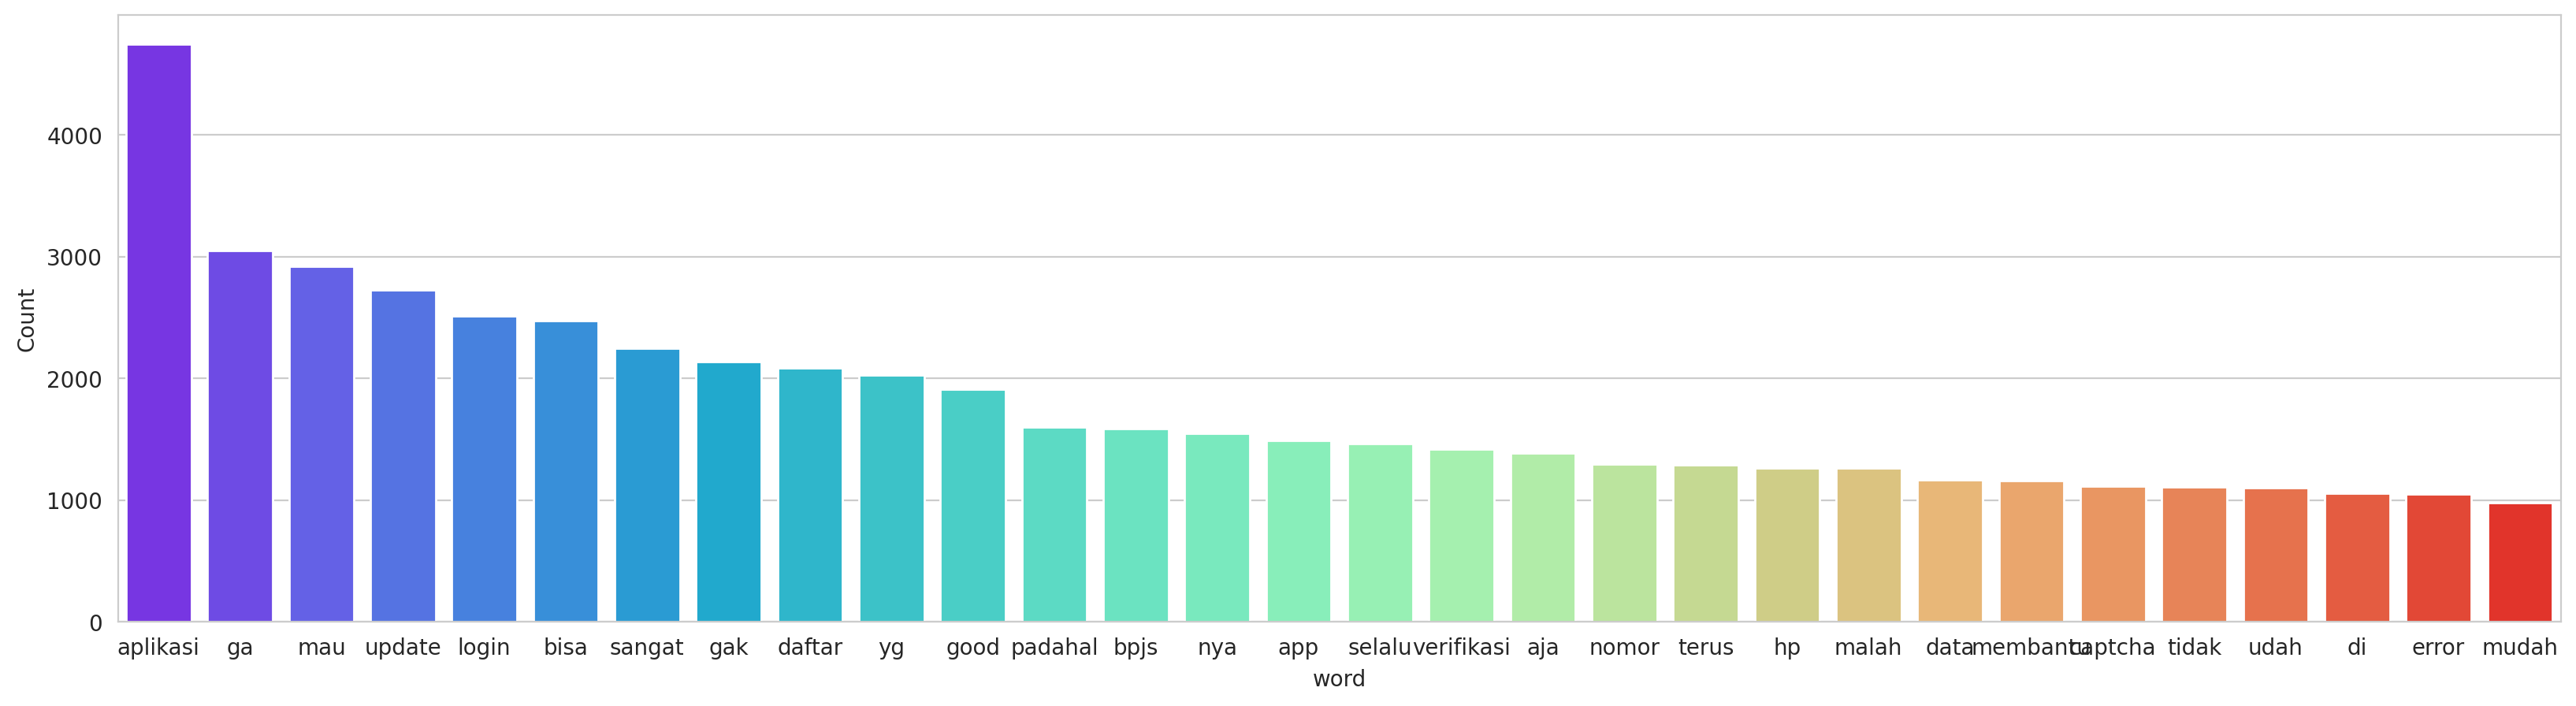

In [ ]:
freq_words(df_jknrev['content'])

In [ ]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_jknrev_stopwords['wordCount'] = [len(review.split()) for review in df_jknrev_stopwords['content']]
df_jknrev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_jknrev_stopwords['review_after_stopwords']]


NameError: name 'df_nhsrev_stopwords' is not defined